In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms
from torchinfo import summary

from torch import nn

from tqdm.auto import tqdm
from typing import Tuple, List, Dict
import os
import sys
parent_dir = os.path.abspath('..')

In [20]:
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from Going_modular.going_modular import data_setup, engine, model_builder, utils
from Going_modular.going_modular.utils import save_model
from Experiment_Tracking.experiment_tracking import set_seed


In [41]:
import config
from config import train_dir, test_dir
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=config.train_dir,
    test_dir=config.test_dir, 
    transform=manual_transforms,  # e.g. data_setup.auto_transform or manual
    batch_size=32,
)


In [ ]:
import os 
print(parent_dir)
print(os.listdir(os.path.join(parent_dir, "Experiment_Tracking")))
import Experiment_Tracking
print(Experiment_Tracking.__path__) 

_NamespacePath(['e:\\Student\\PyTorch\\Code\\Experiment_Tracking'])


In [42]:
train_dir, test_dir, class_names, train_dataloader, test_dataloader

(WindowsPath('E:/Student/PyTorch/Code/dataset/data/pizza_steak_sushi/train'),
 WindowsPath('E:/Student/PyTorch/Code/dataset/data/pizza_steak_sushi/test'),
 ['pizza', 'steak', 'sushi'],
 <torch.utils.data.dataloader.DataLoader at 0x2868ad79c10>)

In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [43]:
image_batch, label_batch = next(iter(train_dataloader))
image,label = image_batch[0], label_batch[0]
image, label, image.shape, label, class_names[label]

(tensor([[[0.2824, 0.2863, 0.2706,  ..., 0.0314, 0.0235, 0.0314],
          [0.3686, 0.3725, 0.3765,  ..., 0.0353, 0.0314, 0.0392],
          [0.4784, 0.4784, 0.4902,  ..., 0.0431, 0.0392, 0.0353],
          ...,
          [0.7137, 0.7216, 0.7294,  ..., 0.2353, 0.2196, 0.2157],
          [0.6745, 0.7020, 0.7137,  ..., 0.2510, 0.2314, 0.2157],
          [0.6471, 0.6863, 0.6784,  ..., 0.2667, 0.2353, 0.2196]],
 
         [[0.3882, 0.3882, 0.3647,  ..., 0.0431, 0.0431, 0.0510],
          [0.4627, 0.4667, 0.4627,  ..., 0.0471, 0.0510, 0.0588],
          [0.5647, 0.5647, 0.5765,  ..., 0.0510, 0.0471, 0.0510],
          ...,
          [0.7137, 0.7255, 0.7373,  ..., 0.0392, 0.0314, 0.0235],
          [0.6863, 0.7098, 0.7255,  ..., 0.0392, 0.0353, 0.0275],
          [0.6706, 0.7059, 0.6980,  ..., 0.0392, 0.0353, 0.0275]],
 
         [[0.4745, 0.4745, 0.4667,  ..., 0.0314, 0.0275, 0.0353],
          [0.4902, 0.4941, 0.5098,  ..., 0.0353, 0.0353, 0.0392],
          [0.5608, 0.5569, 0.5725,  ...,

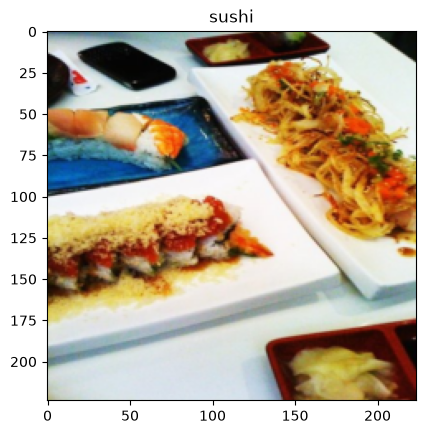

In [44]:
import matplotlib.pyplot as plt
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.show()